# Logistic Regression

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [109]:
from sklearn.datasets import load_iris

In [110]:
data=load_iris()
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [111]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [112]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [113]:
data.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [114]:
data.target 

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [115]:
data.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [116]:
df=pd.DataFrame(data.data, columns=data.feature_names)
df['target']=data.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [117]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [118]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [119]:
df.sample(1)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
50,7.0,3.2,4.7,1.4,1


In [120]:
df.target.unique()

array([0, 1, 2])

In [121]:
# For binary classification >> only two class needed, so we will  filter out class 2

df=df[df['target'] !=2]
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,1
96,5.7,2.9,4.2,1.3,1
97,6.2,2.9,4.3,1.3,1
98,5.1,2.5,3.0,1.1,1


In [122]:
df.target.unique()

array([0, 1])

In [123]:
x=df.iloc[:, :-1]
y=df.iloc[:, -1]

In [124]:
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
95,5.7,3.0,4.2,1.2
96,5.7,2.9,4.2,1.3
97,6.2,2.9,4.3,1.3
98,5.1,2.5,3.0,1.1


In [125]:
y

0     0
1     0
2     0
3     0
4     0
     ..
95    1
96    1
97    1
98    1
99    1
Name: target, Length: 100, dtype: int64

## Data Split

In [126]:
# train test split

In [127]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size =0.20,random_state=1)

In [128]:
x_train

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
2,4.7,3.2,1.3,0.2
73,6.1,2.8,4.7,1.2
97,6.2,2.9,4.3,1.3
62,6.0,2.2,4.0,1.0
19,5.1,3.8,1.5,0.3
...,...,...,...,...
75,6.6,3.0,4.4,1.4
9,4.9,3.1,1.5,0.1
72,6.3,2.5,4.9,1.5
12,4.8,3.0,1.4,0.1


In [129]:
y_train

2     0
73    1
97    1
62    1
19    0
     ..
75    1
9     0
72    1
12    0
37    0
Name: target, Length: 80, dtype: int64

In [130]:
x_test

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
80,5.5,2.4,3.8,1.1
84,5.4,3.0,4.5,1.5
33,5.5,4.2,1.4,0.2
81,5.5,2.4,3.7,1.0
93,5.0,2.3,3.3,1.0
17,5.1,3.5,1.4,0.3
36,5.5,3.5,1.3,0.2
82,5.8,2.7,3.9,1.2
69,5.6,2.5,3.9,1.1
65,6.7,3.1,4.4,1.4


In [131]:
y_test

80    1
84    1
33    0
81    1
93    1
17    0
36    0
82    1
69    1
65    1
92    1
39    0
56    1
52    1
51    1
32    0
31    0
44    0
78    1
10    0
Name: target, dtype: int64

## Model Training

In [132]:
from sklearn.linear_model import LogisticRegression

In [133]:
classifier=LogisticRegression()
classifier

LogisticRegression()

In [134]:
classifier.fit(x_train,y_train)

LogisticRegression()

In [135]:
y_pred=classifier.predict(x_test)
y_pred

array([1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0])

In [136]:
classifier.predict_proba(x_test) # corresponding to higher priority class is predicted, cuttoff is 0.5

array([[0.04043262, 0.95956738],
       [0.01046123, 0.98953877],
       [0.98706759, 0.01293241],
       [0.05440516, 0.94559484],
       [0.1383348 , 0.8616652 ],
       [0.97966131, 0.02033869],
       [0.98204504, 0.01795496],
       [0.03292232, 0.96707768],
       [0.03380573, 0.96619427],
       [0.00850516, 0.99149484],
       [0.02466034, 0.97533966],
       [0.97515854, 0.02484146],
       [0.00517837, 0.99482163],
       [0.00238366, 0.99761634],
       [0.0077453 , 0.9922547 ],
       [0.98619342, 0.01380658],
       [0.96597536, 0.03402464],
       [0.94907826, 0.05092174],
       [0.00735493, 0.99264507],
       [0.97742977, 0.02257023]])

### Evaluation matrics

In [137]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [138]:
confusion_matrix(y_test,y_pred)

array([[ 8,  0],
       [ 0, 12]])

In [139]:
accuracy_score(y_test,y_pred)

1.0

In [140]:
print(classification_report(y_test,y_pred)) 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [141]:
from sklearn.metrics import roc_curve, auc

# get predicted probabilities of class 1
classifier.predict_proba(x_test)[:,1] # probability for one class

array([0.95956738, 0.98953877, 0.01293241, 0.94559484, 0.8616652 ,
       0.02033869, 0.01795496, 0.96707768, 0.96619427, 0.99149484,
       0.97533966, 0.02484146, 0.99482163, 0.99761634, 0.9922547 ,
       0.01380658, 0.03402464, 0.05092174, 0.99264507, 0.02257023])

In [142]:
y_pred_proba=classifier.predict_proba(x_test)[:,1] 
y_pred_proba

array([0.95956738, 0.98953877, 0.01293241, 0.94559484, 0.8616652 ,
       0.02033869, 0.01795496, 0.96707768, 0.96619427, 0.99149484,
       0.97533966, 0.02484146, 0.99482163, 0.99761634, 0.9922547 ,
       0.01380658, 0.03402464, 0.05092174, 0.99264507, 0.02257023])

### Receiver Operating Characteristics Curve
- inputs : y_test, y_pred_proba. It will return TPR, FPR with different cutoff of probabilites

In [143]:
fpr, tpr, thresholds=roc_curve(y_test, y_pred_proba)

In [144]:
thresholds

array([       inf, 0.99761634, 0.8616652 , 0.01293241])

In [145]:
tpr

array([0.        , 0.08333333, 1.        , 1.        ])

In [146]:
fpr

array([0., 0., 0., 1.])

In [147]:
roc_auc=auc(fpr, tpr)
roc_auc

np.float64(1.0)

### plot roc-auc curve

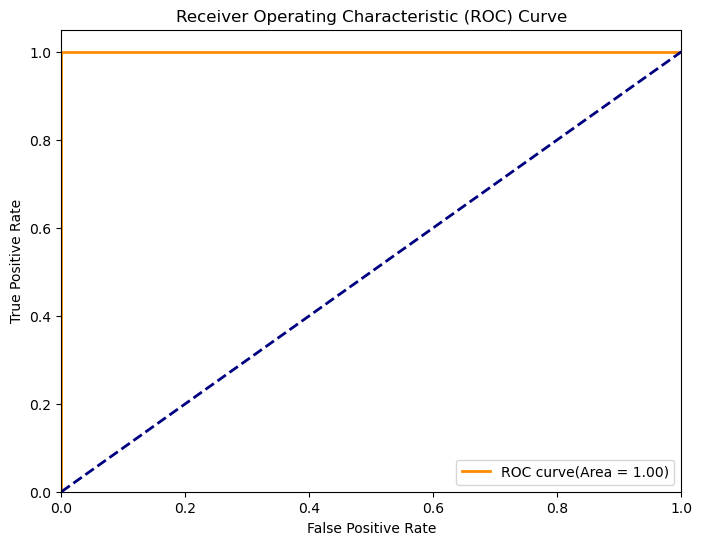

In [148]:
plt.figure(figsize = (8,6))
plt.plot(fpr , tpr , color = 'darkorange' , linewidth = 2 , label = 'ROC curve(Area = %0.2f)' % roc_auc) # plot ROC curve 
plt.plot([0,1], [0,1] , color = 'navy', linewidth = 2 , linestyle = '--') # plot the diagonal line represnting random gusseing
plt.xlim([0.0 , 1.0]) # set x- axis limit 
plt.ylim([0.0 , 1.05]) # set y axis limit 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc = 'lower right')
plt.show()

### Cross Validation >> 
- Randomized search CV or grid search CV >> Generic method with hyperparameter tuning
- Logistic regression CV >> Specific to logistic regression
- KFold >> generic method

In [149]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import KFold

In [150]:
cv= KFold(n_splits=5)
cv
# suffle : bool, default: false
# whether to shuffle the data before splitting into btaches
# Note that the sample within each split will not be shuffled

KFold(n_splits=5, random_state=None, shuffle=False)

In [151]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(classifier, x_train, y_train, cv=cv, scoring='accuracy')
scores

array([1., 1., 1., 1., 1.])

In [152]:
np.mean(scores)

np.float64(1.0)

# 2------

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [154]:
from sklearn.datasets import make_classification
x,y=make_classification(n_samples=1000, n_features=10, n_redundant=5, n_informative=5,n_classes=2,random_state=1)

In [155]:
x

array([[ 2.56999479, -0.13019997,  3.16075093, ..., -1.93094078,
         3.26130366,  2.05692145],
       [ 0.34129317,  2.51321418, -0.80416572, ...,  6.24734437,
        -1.92769365,  2.9503149 ],
       [ 2.27539972,  3.36561455,  0.17164362, ...,  2.74693781,
         0.13492444,  2.00339547],
       ...,
       [ 0.5234359 ,  1.90466429,  0.93243365, ...,  1.53945231,
         1.90646166,  1.99458587],
       [ 1.33747921,  3.25859684,  0.78792366, ...,  5.18788314,
        -0.82071083,  3.51411431],
       [-0.98534299,  0.83919047,  2.5820803 , ...,  3.04705685,
         0.66885641,  3.32838496]])

In [156]:
y

array([1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,

In [157]:
len(y)

1000

In [158]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.3, random_state=1)

In [159]:
x_train.shape, x_test.shape

((700, 10), (300, 10))

In [160]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model

LogisticRegression()

In [161]:
model.fit(x_train, y_train)

LogisticRegression()

In [162]:
y_pred=model.predict(x_test)
y_pred

array([1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0])

## Model evaluation

In [163]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [164]:
confusion_matrix(y_test, y_pred)

array([[129,  13],
       [ 34, 124]])

In [165]:
accuracy_score(y_test, y_pred)

0.8433333333333334

In [166]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.91      0.85       142
           1       0.91      0.78      0.84       158

    accuracy                           0.84       300
   macro avg       0.85      0.85      0.84       300
weighted avg       0.85      0.84      0.84       300



In [167]:
from sklearn.metrics import roc_curve , auc
y_pred_proba=model.predict_proba(x_test)[: , 1] # prob of one class
y_pred_proba

array([0.98074543, 0.1630346 , 0.28836826, 0.13404523, 0.55118737,
       0.093381  , 0.96196454, 0.30121948, 0.12350803, 0.95731226,
       0.08778761, 0.42049714, 0.72313926, 0.23255511, 0.58121438,
       0.66837244, 0.94905128, 0.85972623, 0.97062375, 0.07234521,
       0.44982165, 0.95676726, 0.81009427, 0.10033704, 0.90917135,
       0.55589431, 0.14145472, 0.4616435 , 0.50964656, 0.17344476,
       0.24931498, 0.76014755, 0.09988604, 0.64112515, 0.95883863,
       0.9780211 , 0.98800651, 0.0543648 , 0.03435789, 0.46141478,
       0.08374178, 0.35333259, 0.02083056, 0.41419338, 0.26807876,
       0.17827763, 0.10715494, 0.37105347, 0.28588311, 0.05294433,
       0.13359114, 0.04523728, 0.62836506, 0.97984677, 0.59864183,
       0.10748243, 0.07895498, 0.17213621, 0.9844883 , 0.96882693,
       0.99515672, 0.90155236, 0.87722561, 0.36500043, 0.94415526,
       0.19466362, 0.06183406, 0.09986673, 0.45158351, 0.72166411,
       0.25229704, 0.02143247, 0.89969779, 0.5412839 , 0.98427

In [168]:
# Calculate roc corve
fpr,tpr,thresholds=roc_curve(y_test, y_pred_proba)
# calculate AUC score
roc_auc=auc(fpr,tpr)

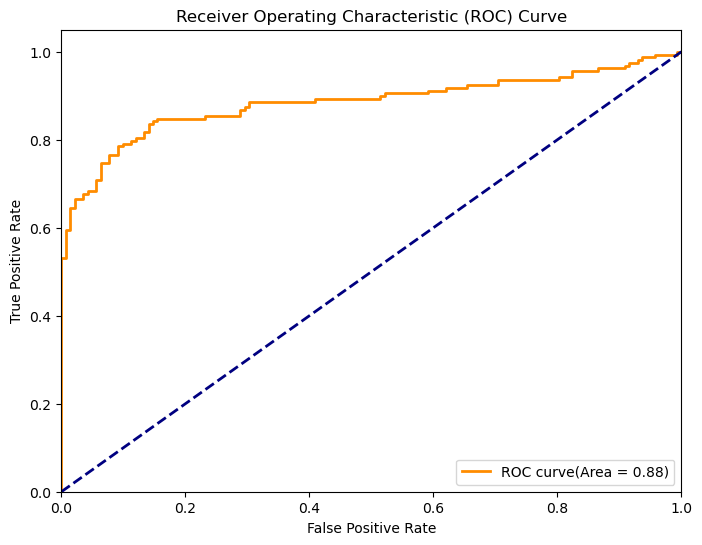

In [169]:
# plot ROC curve

plt.figure(figsize = (8,6))
plt.plot(fpr , tpr , color = 'darkorange' , linewidth = 2 , label = 'ROC curve(Area = %0.2f)' % roc_auc) # plot ROC curve 
plt.plot([0,1], [0,1] , color = 'navy', linewidth = 2 , linestyle = '--') # plot the diagonal line represnting random gusseing
plt.xlim([0.0 , 1.0]) # set x- axis limit 
plt.ylim([0.0 , 1.05]) # set y axis limit 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc = 'lower right')
plt.show()

In [170]:
# By defsult prediction class is decided with cutoff 0.5
#but if we want to decide your own cutoff, we have to use precision, recall, accuracy tradeoff
# sensitivity specificity, accuracy tradeoff

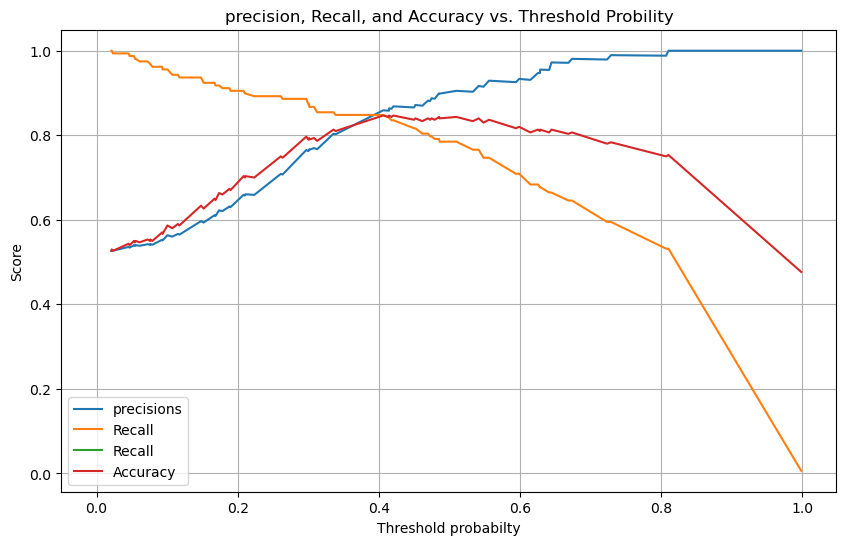

In [171]:
# import necessary lib
from sklearn.metrics import precision_score, recall_score, accuracy_score

# Calculate presicion, recall, and accuracy for different threshold probabilities
threshods=np.linspace(0,1,100)
precisions=[]
recalls=[]
accuracies=[]

for threshold in thresholds:
    y_pred_threshold=(y_pred_proba >= threshold).astype(int)
    precision=precision_score(y_test, y_pred_threshold)
    recall=recall_score(y_test,y_pred_threshold)
    accuracy=accuracy_score(y_test, y_pred_threshold)
    precisions.append(precision)
    recalls.append(recall)
    accuracies.append(accuracy)

# Plot preciscion , recall, and accuracy threshold probilites

plt.figure(figsize = (10,6))
plt.plot(thresholds, precisions, label='precisions')
plt.plot(thresholds, recalls, recall,label='Recall')
plt.plot(thresholds, accuracies, label='Accuracy')
plt.xlabel('Threshold probabilty')
plt.ylabel('Score')
plt.title('precision, Recall, and Accuracy vs. Threshold Probility')
plt.legend()
plt.grid(True)
plt.show()

In [172]:
# 0.4 is my optimal threshold  based on precision-recall-accuracy tradeoff

In [173]:
new_pred_levels=np.where(y_pred_proba >0.4, 1,0)
new_pred_levels

array([1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0])

In [174]:
confusion_matrix(y_test, new_pred_levels)

array([[119,  23],
       [ 24, 134]])

In [175]:
accuracy_score(y_test, new_pred_levels)

0.8433333333333334

In [176]:
print(classification_report(y_test, new_pred_levels))

              precision    recall  f1-score   support

           0       0.83      0.84      0.84       142
           1       0.85      0.85      0.85       158

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300



In [177]:
# Cross validation

In [178]:
from sklearn.model_selection import KFold
cv=KFold(n_splits=5)

In [179]:
cv

KFold(n_splits=5, random_state=None, shuffle=False)

In [180]:
from sklearn.model_selection import cross_val_score
acc=cross_val_score(model, x_train, y_train, cv=cv)
acc

array([0.78571429, 0.79285714, 0.8       , 0.84285714, 0.8       ])

In [181]:
np.mean(acc)

np.float64(0.8042857142857143)

# 3----

## Hyperparameter tuning

In [182]:
# randomized
# grid

In [183]:
from sklearn.model_selection import GridSearchCV
params={'penalty':('l1','l2','elasticnet'), 'C': [1,2,10,20,30,40]}

In [184]:
params

{'penalty': ('l1', 'l2', 'elasticnet'), 'C': [1, 2, 10, 20, 30, 40]}

In [185]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression()
classifier

LogisticRegression()

In [186]:
clf=GridSearchCV(classifier, param_grid=params, cv=5, verbose=2)
clf

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [1, 2, 10, 20, 30, 40],
                         'penalty': ('l1', 'l2', 'elasticnet')},
             verbose=2)

In [187]:
clf.fit(x_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END ....................................C=1, penalty=l1; total time=   0.0s
[CV] END ....................................C=1, penalty=l1; total time=   0.0s
[CV] END ....................................C=1, penalty=l1; total time=   0.0s
[CV] END ....................................C=1, penalty=l1; total time=   0.0s
[CV] END ....................................C=1, penalty=l1; total time=   0.0s
[CV] END ....................................C=1, penalty=l2; total time=   0.0s
[CV] END ....................................C=1, penalty=l2; total time=   0.0s
[CV] END ....................................C=1, penalty=l2; total time=   0.0s
[CV] END ....................................C=1, penalty=l2; total time=   0.0s
[CV] END ....................................C=1, penalty=l2; total time=   0.0s
[CV] END ............................C=1, penalty=elasticnet; total time=   0.0s
[CV] END ............................C=1, penalt

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [1, 2, 10, 20, 30, 40],
                         'penalty': ('l1', 'l2', 'elasticnet')},
             verbose=2)

In [188]:
clf.best_params_

{'C': 1, 'penalty': 'l2'}

In [189]:
clf.best_score_

np.float64(0.8042857142857145)

In [190]:
# Now prediction two ways, directy predict  from best_estimator or build a seperate model
clf.best_estimator_.predict(x_test)

array([1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0])

In [191]:
model=LogisticRegression(C=1, penalty='l2')
model

LogisticRegression(C=1)

In [192]:
model.fit(x_train, y_train)

LogisticRegression(C=1)

In [193]:
y_pred=model.predict(x_test)
y_pred

array([1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0])

In [194]:
model.predict_proba(x_test)

array([[0.01925457, 0.98074543],
       [0.8369654 , 0.1630346 ],
       [0.71163174, 0.28836826],
       [0.86595477, 0.13404523],
       [0.44881263, 0.55118737],
       [0.906619  , 0.093381  ],
       [0.03803546, 0.96196454],
       [0.69878052, 0.30121948],
       [0.87649197, 0.12350803],
       [0.04268774, 0.95731226],
       [0.91221239, 0.08778761],
       [0.57950286, 0.42049714],
       [0.27686074, 0.72313926],
       [0.76744489, 0.23255511],
       [0.41878562, 0.58121438],
       [0.33162756, 0.66837244],
       [0.05094872, 0.94905128],
       [0.14027377, 0.85972623],
       [0.02937625, 0.97062375],
       [0.92765479, 0.07234521],
       [0.55017835, 0.44982165],
       [0.04323274, 0.95676726],
       [0.18990573, 0.81009427],
       [0.89966296, 0.10033704],
       [0.09082865, 0.90917135],
       [0.44410569, 0.55589431],
       [0.85854528, 0.14145472],
       [0.5383565 , 0.4616435 ],
       [0.49035344, 0.50964656],
       [0.82655524, 0.17344476],
       [0.

In [195]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[129  13]
 [ 34 124]]
0.8433333333333334
              precision    recall  f1-score   support

           0       0.79      0.91      0.85       142
           1       0.91      0.78      0.84       158

    accuracy                           0.84       300
   macro avg       0.85      0.85      0.84       300
weighted avg       0.85      0.84      0.84       300



In [196]:
# Randomized search cv>> it will take some combination

In [197]:
from sklearn.model_selection import RandomizedSearchCV

In [198]:
randomized_clf=RandomizedSearchCV(classifier, param_distributions=params, n_iter=10, cv=5)
randomized_clf

RandomizedSearchCV(cv=5, estimator=LogisticRegression(),
                   param_distributions={'C': [1, 2, 10, 20, 30, 40],
                                        'penalty': ('l1', 'l2', 'elasticnet')})

In [199]:
randomized_clf.fit(x_train, y_train)

RandomizedSearchCV(cv=5, estimator=LogisticRegression(),
                   param_distributions={'C': [1, 2, 10, 20, 30, 40],
                                        'penalty': ('l1', 'l2', 'elasticnet')})

In [200]:
randomized_clf.best_score_

np.float64(0.8042857142857145)

In [201]:
randomized_clf.best_params_

{'penalty': 'l2', 'C': 1}

In [202]:
# Build ML  model with these params
# or simply use best_estimator. 

# 4------

# Multiclass Classification Implementation

In [227]:
from sklearn.datasets import make_classification
x,y=make_classification(n_samples=1000, n_features=10,n_redundant=5, n_informative=5, n_classes=3, random_state=1)

In [228]:
x

array([[ 1.89149379, -0.39847585,  1.63856893, ...,  0.58810926,
        -0.02542177, -0.52835426],
       [ 1.86913773, -0.56336215,  2.03411807, ..., -0.55633   ,
        -0.27340013,  0.72129251],
       [ 1.95259701, -2.83144572,  0.19055535, ..., -0.60957741,
        -2.07750191, -1.75469982],
       ...,
       [ 1.98033054,  1.37228804,  1.67376262, ...,  2.75687956,
        -0.20719842,  0.39299534],
       [-1.54305631, -0.27530218,  0.38744703, ...,  0.72769107,
         0.51983329, -1.92306657],
       [ 1.17970389, -3.3812155 , -0.1498426 , ...,  1.24640268,
        -4.00356845, -3.01027048]])

In [229]:
y

array([1, 0, 1, 2, 0, 2, 2, 2, 0, 0, 1, 0, 2, 2, 0, 1, 1, 0, 1, 0, 2, 0,
       2, 2, 0, 0, 2, 0, 1, 1, 2, 1, 0, 2, 0, 0, 0, 1, 2, 2, 2, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 2, 1, 1, 2, 2, 2, 1, 0, 2, 2, 2, 1, 2, 1,
       1, 0, 0, 0, 2, 1, 1, 0, 0, 0, 0, 0, 2, 1, 2, 0, 2, 0, 1, 2, 2, 2,
       0, 1, 0, 2, 1, 0, 2, 1, 1, 2, 0, 1, 0, 0, 1, 1, 1, 0, 2, 2, 2, 2,
       1, 2, 0, 2, 0, 0, 0, 0, 0, 1, 2, 2, 1, 2, 2, 2, 2, 2, 1, 0, 0, 1,
       0, 0, 2, 2, 0, 0, 1, 1, 1, 1, 0, 2, 0, 1, 2, 0, 2, 1, 2, 0, 0, 1,
       0, 0, 2, 2, 2, 2, 2, 1, 2, 0, 1, 2, 2, 0, 2, 1, 0, 0, 0, 0, 0, 0,
       2, 0, 2, 1, 2, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 2, 1, 0, 2, 1, 1, 0,
       1, 1, 1, 1, 2, 1, 0, 2, 2, 1, 2, 1, 1, 2, 0, 0, 0, 2, 2, 2, 0, 2,
       0, 1, 1, 2, 1, 1, 1, 1, 2, 1, 0, 1, 1, 2, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 1, 0, 1, 0, 0, 1, 1, 2, 2, 2, 2, 1, 2, 1, 1, 0, 1, 1, 1, 1, 2,
       1, 2, 1, 2, 0, 0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 0, 1, 0, 0, 1, 1, 1,
       1, 2, 1, 2, 2, 2, 1, 0, 0, 1, 0, 0, 2, 1, 1,

In [231]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.30, random_state=1)

In [232]:
x_train.shape

(700, 10)

## ove vs rest ____________

In [233]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(multi_class='ovr', solver='lbfgs')

In [234]:
model.fit(x_train,y_train)

LogisticRegression(multi_class='ovr')

In [235]:
y_pred=model.predict(x_test)
y_pred

array([1, 2, 0, 2, 2, 0, 1, 1, 2, 2, 0, 0, 0, 2, 0, 0, 0, 1, 1, 2, 0, 0,
       2, 1, 2, 2, 2, 1, 2, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 2, 2, 0, 1,
       0, 1, 1, 1, 2, 2, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 2, 2, 2, 1, 2, 0,
       0, 2, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 0, 2, 2, 1, 0, 1, 2, 2, 0, 1,
       1, 1, 2, 0, 2, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 2, 0, 2, 2, 1, 1, 1,
       1, 1, 2, 0, 0, 1, 2, 1, 2, 0, 0, 2, 2, 0, 2, 0, 1, 0, 2, 1, 1, 2,
       1, 1, 1, 2, 0, 2, 1, 0, 1, 0, 1, 1, 0, 2, 2, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 2, 0, 2, 2, 0, 0, 2, 2, 2, 0, 0, 0, 2, 1, 1, 0, 1, 1, 2, 0,
       0, 2, 2, 1, 2, 0, 0, 0, 0, 0, 1, 2, 2, 0, 1, 0, 2, 2, 1, 1, 2, 1,
       0, 1, 2, 1, 1, 0, 1, 0, 0, 0, 1, 2, 0, 0, 2, 0, 1, 0, 0, 0, 1, 2,
       1, 2, 0, 1, 0, 0, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 0, 1, 2, 1, 2,
       0, 1, 0, 1, 1, 0, 0, 0, 2, 2, 0, 1, 1, 1, 1, 2, 2, 1, 2, 2, 0, 2,
       0, 2, 2, 0, 0, 0, 0, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 2, 0, 0, 1, 2,
       1, 1, 0, 1, 0, 0, 1, 2, 0, 1, 0, 2, 2, 1])

In [236]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[75 21  3]
 [10 58 21]
 [23 14 75]]
0.6933333333333334
              precision    recall  f1-score   support

           0       0.69      0.76      0.72        99
           1       0.62      0.65      0.64        89
           2       0.76      0.67      0.71       112

    accuracy                           0.69       300
   macro avg       0.69      0.69      0.69       300
weighted avg       0.70      0.69      0.69       300



## Multinomial ___________

In [237]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.30, random_state=1)
model=LogisticRegression(multi_class='multinomial', solver='lbfgs')
model

LogisticRegression(multi_class='multinomial')

In [238]:
model.fit(x_train,y_train)

LogisticRegression(multi_class='multinomial')

In [240]:
y_pred=model.predict(x_test)
y_pred

array([1, 2, 0, 2, 2, 0, 1, 1, 2, 2, 0, 0, 0, 2, 0, 0, 0, 1, 1, 2, 0, 0,
       2, 1, 2, 2, 2, 0, 2, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 2, 2, 2, 1,
       0, 1, 1, 1, 2, 2, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 2, 2, 2, 1, 2, 0,
       0, 2, 0, 0, 2, 0, 2, 1, 1, 1, 2, 2, 0, 2, 2, 1, 0, 1, 2, 2, 2, 1,
       1, 1, 2, 0, 2, 2, 0, 2, 1, 0, 0, 0, 2, 1, 1, 2, 0, 2, 2, 1, 1, 1,
       1, 1, 2, 0, 0, 1, 2, 1, 2, 0, 0, 2, 2, 0, 2, 0, 1, 0, 2, 0, 1, 2,
       2, 1, 1, 1, 0, 2, 1, 0, 1, 0, 1, 1, 0, 2, 2, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 2, 0, 2, 2, 0, 0, 2, 2, 2, 0, 0, 0, 2, 1, 1, 0, 1, 1, 1, 0,
       0, 2, 2, 1, 2, 0, 0, 0, 0, 0, 1, 2, 2, 0, 1, 0, 2, 2, 1, 1, 2, 1,
       0, 1, 2, 1, 1, 0, 1, 0, 0, 0, 1, 2, 0, 2, 2, 0, 1, 0, 0, 0, 1, 2,
       1, 2, 0, 1, 0, 0, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 0, 1, 2, 1, 2,
       0, 1, 0, 1, 1, 0, 0, 0, 2, 2, 0, 1, 1, 1, 1, 2, 2, 1, 2, 2, 0, 2,
       0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 2, 0, 0, 1, 2,
       1, 1, 0, 1, 0, 0, 0, 2, 0, 1, 0, 2, 2, 1])

In [241]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[70 21  8]
 [13 57 19]
 [21 13 78]]
0.6833333333333333
              precision    recall  f1-score   support

           0       0.67      0.71      0.69        99
           1       0.63      0.64      0.63        89
           2       0.74      0.70      0.72       112

    accuracy                           0.68       300
   macro avg       0.68      0.68      0.68       300
weighted avg       0.69      0.68      0.68       300



### -> Roc auc only for binaty classification 

# 4-----

In [243]:
## Implementation of multiclass classification

In [246]:
from sklearn.datasets import load_iris

In [248]:
data=load_iris()
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [249]:
data.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [250]:
data.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [251]:
print(data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [252]:
data.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [253]:
df=pd.DataFrame(data.data, columns=data.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [256]:
df['target']=data.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [257]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [258]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [259]:
df.target.unique()

array([0, 1, 2])

In [260]:
df.target.value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [261]:
df.sample(1)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
127,6.1,3.0,4.9,1.8,2


In [263]:
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [265]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Length: 150, dtype: bool

In [266]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

In [268]:
x=df.iloc[:,:-1]
y=df.iloc[:, -1]

In [269]:
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [270]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [281]:
from sklearn.model_selection import  train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=1)

In [282]:
x_train

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
91,6.1,3.0,4.6,1.4
135,7.7,3.0,6.1,2.3
69,5.6,2.5,3.9,1.1
128,6.4,2.8,5.6,2.1
114,5.8,2.8,5.1,2.4
...,...,...,...,...
133,6.3,2.8,5.1,1.5
137,6.4,3.1,5.5,1.8
72,6.3,2.5,4.9,1.5
140,6.7,3.1,5.6,2.4


In [285]:
x_train.shape,x_test.shape

((120, 4), (30, 4))

In [288]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression(max_iter=300)
classifier

LogisticRegression(max_iter=300)

In [289]:
classifier.fit(x_train, y_train)

LogisticRegression(max_iter=300)

In [290]:
y_pred=classifier.predict(x_test)
y_pred

array([0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 1, 0, 2, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       2, 0, 2, 1, 0, 0, 1, 2])

In [292]:
classifier.predict_proba(x_test)

array([[9.84858502e-01, 1.51414761e-02, 2.15433031e-08],
       [2.74892124e-01, 7.22452684e-01, 2.65519251e-03],
       [6.33568154e-03, 8.89188353e-01, 1.04475966e-01],
       [9.85552631e-01, 1.44473060e-02, 6.30394762e-08],
       [1.20874463e-06, 1.90846922e-02, 9.80914099e-01],
       [4.54970252e-03, 6.28114377e-01, 3.67335920e-01],
       [1.48334717e-04, 1.27993131e-01, 8.71858534e-01],
       [9.57821915e-01, 4.21768582e-02, 1.22631883e-06],
       [9.69473537e-01, 3.05261522e-02, 3.10434985e-07],
       [9.84326472e-06, 2.71234251e-02, 9.72866732e-01],
       [1.89620192e-02, 8.79677529e-01, 1.01360452e-01],
       [9.66592603e-01, 3.34069565e-02, 4.40308846e-07],
       [4.77405743e-06, 3.10603150e-02, 9.68934911e-01],
       [7.19257183e-03, 8.01920971e-01, 1.90886457e-01],
       [6.99213004e-03, 7.49159136e-01, 2.43848734e-01],
       [9.88031784e-01, 1.19681484e-02, 6.76274569e-08],
       [2.25372200e-02, 9.36920294e-01, 4.05424860e-02],
       [1.09370893e-02, 6.81885

In [293]:
1.51414761e-02

0.0151414761

In [295]:
# Evaluation matrix

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9666666666666667
[[11  0  0]
 [ 0 12  1]
 [ 0  0  6]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.92      0.96        13
           2       0.86      1.00      0.92         6

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
# roc auc can only be calculated for binary classification                                                                                                             